# Physics-Informed Neural Network (PINN) pour l'équation de la chaleur

Dans ce notebook nous étudions l'équation de la chaleur 1D :

$$u_t = α u_{xx}$$

avec :

- α : diffusivité thermique
- x ∈ [0, L]
- t ∈ [0, T]

L'objectif est de comparer :

1. une **solution numérique obtenue par schéma implicite**
2. une **approximation par PINN**

Nous analysons également l'influence du poids physique λ dans la fonction de coût.

La loss utilisée est :

Loss = Loss_data + λ Loss_PDE

## 1. Génération du dataset (schéma implicite)

Nous résolvons l'équation de la chaleur :

$$u_t = \alpha u_{xx}$$

avec :

- condition initiale :  
$$u(x,0) = sin(πx)$$

- conditions aux limites :
u(0,t) = 0  
u(L,t) = 0

La solution est calculée avec un **schéma implicite en temps**, qui est :

- stable
- adapté aux pas de temps élevés.

Les données générées serviront ensuite à entraîner le PINN.

In [14]:
# =========================================================
# 1) GENERATION DU DATASET IMPLICITE
# =========================================================

import numpy as np
import pandas as pd
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import grad

# ---------------------------------------------------------
# Paramètres physiques
# ---------------------------------------------------------
alpha = 0.3
L = 1.0
Tf = 1.0
N = 10000
ht = Tf / N

u0 = lambda x: np.sin(np.pi * x)

# ---------------------------------------------------------
# Paramètres spatiaux
# ---------------------------------------------------------
J = 200
x = np.linspace(0, L, J+1)
x_inner = x[1:-1]
hx = L / J

# ---------------------------------------------------------
# Matrice implicite
# ---------------------------------------------------------
main_diag = (1 + 2*alpha*ht/hx**2) * np.ones(J-1)
off_diag  = (-alpha*ht/hx**2) * np.ones(J-2)
A = diags([off_diag, main_diag, off_diag], [-1,0,1]).tocsc()

# ---------------------------------------------------------
# Stockage
# ---------------------------------------------------------
temperature_data = []
header = ["Time (s)"] + [f"x={xi:.4f}m" for xi in x]
temperature_data.append(header)

U = np.zeros(J+1)
U[1:J] = u0(x_inner)
temperature_data.append([0.0] + U.tolist())

save_every = 50

for n in range(1, N+1):
    b = U[1:J]
    U_new_inner = spsolve(A, b)
    U[1:J] = U_new_inner
    U[0] = 0.0
    U[-1] = 0.0

    if n % save_every == 0:
        temperature_data.append([n*ht] + U.tolist())

df = pd.DataFrame(temperature_data[1:], columns=temperature_data[0])
df.to_csv("temperature_data_implicit.csv", index=False)

print("Dataset généré : temperature_data_implicit.csv")


Dataset généré : temperature_data_implicit.csv


## 2. Visualisation des données

On visualise :

- la solution numérique propre
- la solution avec bruit

Le bruit simule des **mesures expérimentales**, ce qui permet de tester la robustesse du PINN.

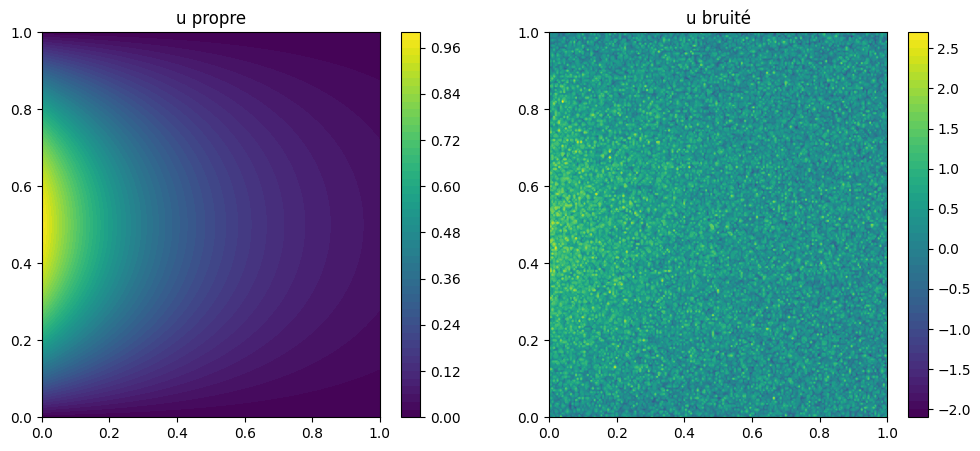

Device : cuda


In [15]:
# =========================================================
# 2) VISUALISATION u PROPRE vs BRUITÉ
# =========================================================
df.to_csv("temperature_data_implicit.csv", index=False)
times = df["Time (s)"].values
x_coords = np.array([float(c.split("=")[1].replace("m","")) for c in df.columns[1:]])

U_clean = df.iloc[:,1:].values
noise=0.5
U_noisy = U_clean + noise *np.random.randn(*U_clean.shape)

TT, XX = np.meshgrid(times, x_coords, indexing="ij")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.contourf(TT, XX, U_clean, 50)
plt.title("u propre")
plt.colorbar()

plt.subplot(1,2,2)
plt.contourf(TT, XX, U_noisy, 50)
plt.title("u bruité")
plt.colorbar()

plt.savefig("comparaisonUproprevsbruite.png", dpi=300, bbox_inches='tight')
plt.show()

# =========================================================
# 3) PREPARATION DES DONNÉES POUR LE PINN
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)

data = []
for i,t in enumerate(times):
    for j,xv in enumerate(x_coords):
        data.append([t, xv, U_noisy[i,j]])

data = np.array(data)
data = torch.tensor(data, dtype=torch.float32).to(device)

t_data = data[:,0:1]
x_data = data[:,1:2]
u_data = data[:,2:3]
Ntot = len(data)



## 4. Architecture du PINN

Le réseau de neurones approxime la solution :

u_θ(t,x)

où θ représente l'ensemble des paramètres du réseau.

Architecture utilisée :

- 3 couches cachées
- 64 neurones par couche
- fonction d'activation : Tanh

Nous imposons également **les conditions initiales et aux limites directement dans la forme de la solution :**

$$u(t,x) = f(x) + t x (1-x) N_θ(t,x)$$

où :

$$f(x) = sin(πx)$$

Cette formulation garantit :

- u(0,x) = sin(πx)
- u(t,0) = 0
- u(t,1) = 0

## 5. Résidu de l'équation différentielle

Le PINN impose que la solution respecte l'équation :

$$u_t = \alpha u_{xx}$$

Le résidu est défini comme :

$$r(t,x) = u_t - \alpha u_{xx}$$

Si le réseau respecte parfaitement la physique :

$$r(t,x) = 0$$

La loss physique est donc :

$$Loss_{PDE} = mean( r(t,x)^2 )$$



## 6. Entraînement du PINN

La fonction de coût combine deux termes :

- erreur sur les données

$$Loss_{data} = mean((u_{pred} - u_{data})^2)$$

- erreur physique

$$Loss_{PDE} = mean((u_t - \alpha u_{xx})^2)$$

La loss totale est :

$$Loss = Loss_{data} + \lambda Loss_{PDE}$$

Le paramètre $\lambda$ contrôle l'influence de la physique.


Epoch 0 | Loss = 413.272614
Epoch 1000 | Loss = 0.284717
Epoch 2000 | Loss = 0.247872


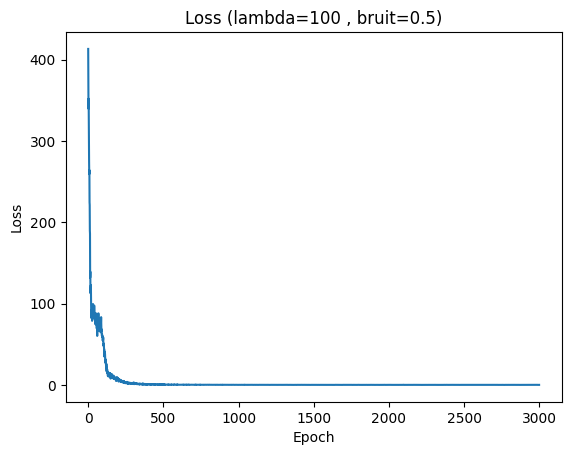

In [42]:
# =========================================================
# 4) PINN
# =========================================================

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,64), nn.Tanh(),
            nn.Linear(64,1)
        )

    def forward(self, t, x):
        inp = torch.cat([t, x], dim=1)
        N = self.net(inp)

        # Condition initiale
        f = torch.sin(np.pi * x)

        # Forme qui impose BC et IC
        return f + t * x * (1 - x) * N

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



# =========================================================
# 5) LOSS PDE
# =========================================================

def loss_pde(model,t,x):
    t.requires_grad_(True)
    x.requires_grad_(True)

    u = model(t,x)
    u_t = grad(u,t,torch.ones_like(u),create_graph=True)[0]
    u_x = grad(u,x,torch.ones_like(u),create_graph=True)[0]
    u_xx = grad(u_x,x,torch.ones_like(u_x),create_graph=True)[0]

    return torch.mean((u_t - alpha*u_xx)**2)



# =========================================================
# 6) ENTRAINEMENT AVEC λ MODIFIABLE
# =========================================================

def train(model, optimizer,
          t_data, x_data, u_data,
          lambda_pde=1.0,
          epochs=3000,
          batch_size=256):

    Ntot = len(t_data)
    loss_history = []

    for epoch in range(epochs):

        # --- Batch aléatoire ---
        idx = torch.randint(0, Ntot, (batch_size,))
        t_batch = t_data[idx]
        x_batch = x_data[idx]
        u_batch = u_data[idx]

        # --- Prédiction ---
        u_pred = model(t_batch, x_batch)

        # --- Loss data ---
        loss_data = torch.mean((u_pred - u_batch)**2)

        # --- Loss PDE ---
        loss_phys = loss_pde(model, t_batch, x_batch)

        # --- Loss totale ---
        loss = loss_data + lambda_pde * loss_phys

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if epoch % 1000 == 0:
            print(f"Epoch {epoch} | Loss = {loss.item():.6f}")

    return loss_history
    
lambda_pde = 100
epochs = 3000
batch_size = 256

loss_history = train(
    model, optimizer,
    t_data, x_data, u_data,
    lambda_pde=lambda_pde,
    epochs=epochs,
    batch_size=batch_size
)


plt.plot(loss_history)
plt.title(f"Loss (lambda={lambda_pde} , bruit={noise})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig(f"perte_{lambda_pde}.png", dpi=300, bbox_inches='tight')
plt.show()



## 7. Prédiction du PINN

Après l'entraînement, on calcule la solution prédite par le réseau :

u_PINN(t,x)

Cette solution est ensuite comparée à la solution numérique obtenue par schéma implicite.

## 8. Analyse de l'erreur

L'erreur absolue est calculée comme :

$$Erreur = | u_{PINN} - u_{exact} |$$

Cette visualisation permet d'identifier :

- les zones où le PINN est précis
- les zones où l'erreur est plus importante

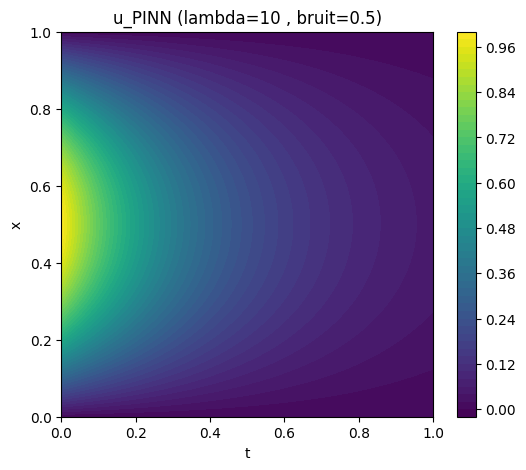

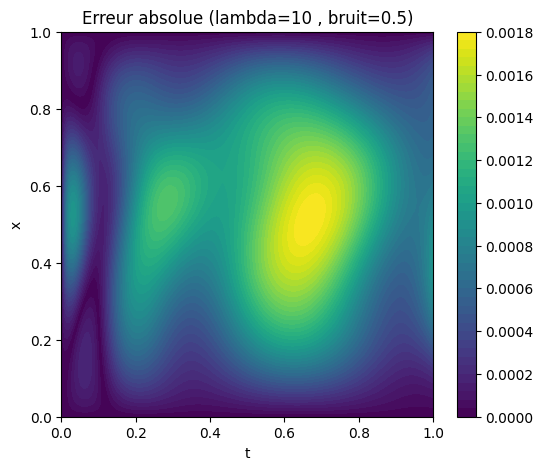

In [39]:


# =========================================================
# 7) PREDICTION PINN + ERREUR
# =========================================================

TT, XX = np.meshgrid(times, x_coords, indexing="ij")
t_torch = torch.tensor(TT.reshape(-1,1),dtype=torch.float32).to(device)
x_torch = torch.tensor(XX.reshape(-1,1),dtype=torch.float32).to(device)

with torch.no_grad():
    U_pinn = model(t_torch, x_torch).cpu().numpy().reshape(TT.shape)

# ---------------------------------------------------------
# u_PINN
# ---------------------------------------------------------
plt.figure(figsize=(6,5))
plt.contourf(TT, XX, U_pinn, 50)
plt.title(f"u_PINN (lambda={lambda_pde} , bruit={noise})")
plt.colorbar()
plt.xlabel("t")
plt.ylabel("x")
plt.savefig(f"u_pinn_lambda_{lambda_pde}.png", dpi=300)
plt.show()

# ---------------------------------------------------------
# Erreur absolue
# ---------------------------------------------------------
err_abs = np.abs(U_pinn - U_clean)

plt.figure(figsize=(6,5))
plt.contourf(TT, XX, err_abs, 50)
plt.title(f"Erreur absolue (lambda={lambda_pde} , bruit={noise})")
plt.colorbar()
plt.xlabel("t")
plt.ylabel("x")
plt.savefig(f"err_abs_lambda_{lambda_pde}.png", dpi=300)
plt.show()







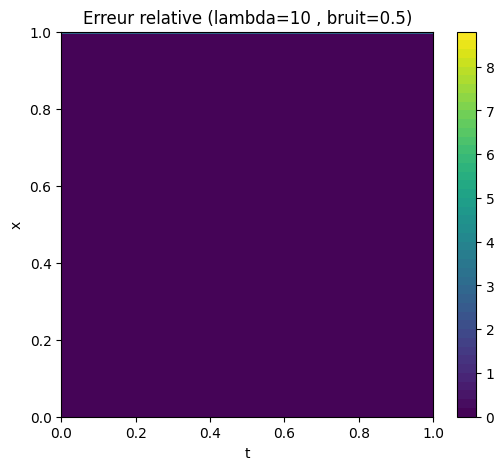

Erreur relative L2 PINN : 0.0028618860069797364


In [40]:
# ---------------------------------------------------------
# Erreur relative
# ---------------------------------------------------------

eps = 1e-8  # évite la division par zéro

err_rel = np.abs(U_pinn - U_clean) / (np.abs(U_clean) +eps)

plt.figure(figsize=(6,5))
plt.contourf(TT, XX, err_rel, 50)
plt.title(f"Erreur relative (lambda={lambda_pde} , bruit={noise})")
plt.colorbar()
plt.xlabel("t")
plt.ylabel("x")
plt.savefig(f"err_rel_lambda_{lambda_pde}.png", dpi=300)
plt.show()
# --- Erreur relative L2 ---
num = np.linalg.norm(U_pinn - U_clean)   # norme du numérateur
den = np.linalg.norm(U_clean)            # norme du dénominateur

err_rel_L2 = num / den

print("Erreur relative L2 PINN :", err_rel_L2)


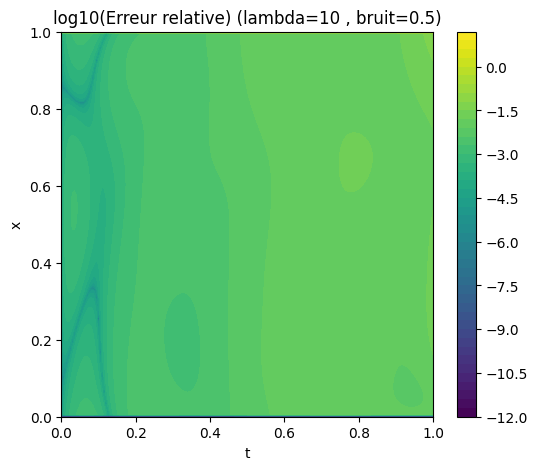

In [41]:
err_rel_log = np.log10(err_rel + 1e-12)

plt.figure(figsize=(6,5))
plt.contourf(TT, XX, err_rel_log, 50)
plt.title(f"log10(Erreur relative) (lambda={lambda_pde} , bruit={noise})")
plt.colorbar()
plt.xlabel("t")
plt.ylabel("x")
plt.savefig(f"err_rel_log10_lambda_{lambda_pde}.png", dpi=300)
plt.show()


## Conclusion

Dans ce notebook nous avons :

1. généré un dataset avec un schéma implicite
2. ajouté du bruit pour simuler des mesures expérimentales
3. entraîné un PINN pour approximer la solution
4. étudié l'influence du paramètre  $\lambda$

Le PINN permet de combiner :

- les données expérimentales
- les lois physiques

ce qui améliore la robustesse de la reconstruction de la solution.